# 중고차 가격 예측 — 회귀 모델 분석

본 노트북은 **전처리 파이프라인 노트북의 실행 결과를 그대로 이어받아** 회귀 모델링을 수행한다.

**전처리 노트북 최종 산출물 (이 노트북이 사용하는 변수)**

| 변수 | 내용 | 전처리 단계 |
|------|------|------------|
| `X_train`, `X_test` | OHE + Target Encoding + StandardScaler 완료 | Step 8~11 |
| `y_train_log`, `y_test_log` | log1p 변환된 가격 | Step 9 |
| `df_final` | 인코딩 완료 전체 데이터 (split 전) | Step 8 |

**비교 구조**

| 버전 | 설명 |
|------|------|
| Baseline | `estimate_msrp` 컬럼 제외 |
| Enhanced | `estimate_msrp` 컬럼 포함 |


## Step 1. 라이브러리 임포트

In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

print("라이브러리 로드 완료")


라이브러리 로드 완료


## Step 2. 전처리 결과 확인

전처리 노트북 실행 후 메모리에 남아있는 변수를 그대로 사용한다.
별도 CSV 로드나 재인코딩 없이 바로 이어서 진행한다.


In [ ]:
# 전처리 완료 변수 확인
print("=" * 55)
print("  전처리 산출물 확인")
print("=" * 55)
print(f"  X_train  : {X_train.shape}")
print(f"  X_test   : {X_test.shape}")
print(f"  y_train_log : {y_train_log.shape}  (log 변환 완료)")
print(f"  y_test_log  : {y_test_log.shape}   (log 변환 완료)")
print()
print(f"  피처 목록 ({X_train.shape[1]}개):")
for col in X_train.columns:
    print(f"    - {col}")
print()
print(f"  estimate_msrp 포함 여부: {'estimate_msrp' in X_train.columns}")


## Step 3. Baseline / Enhanced 데이터 분기

전처리 완료된 `X_train` / `X_test`에서 `estimate_msrp` 컬럼 유무로 두 버전을 분기한다.

- **Baseline** : 기존 차량 정보만 사용 (`estimate_msrp` 제외)
- **Enhanced** : LLM 추정 출고가 포함 (`estimate_msrp` 포함)

> R²는 피처 수가 많아질수록 자동으로 증가하는 특성이 있다.  
> Baseline(피처 n개) vs Enhanced(피처 n+1개) 비교 시 단순 R² 상승이  
> MSRP의 실질 기여인지 피처 수 증가 효과인지 구분하기 위해 **Adjusted R²를 병행** 사용한다.


In [ ]:
# Baseline: estimate_msrp 제외
X_train_base = X_train.drop(columns=['estimate_msrp'], errors='ignore').copy()
X_test_base  = X_test.drop(columns=['estimate_msrp'],  errors='ignore').copy()

# Enhanced: 전처리 결과 그대로 (estimate_msrp 포함)
X_train_enh  = X_train.copy()
X_test_enh   = X_test.copy()

print(f"Baseline  피처 수: {X_train_base.shape[1]}개")
print(f"Enhanced  피처 수: {X_train_enh.shape[1]}개")
print(f"  차이: estimate_msrp 1개")
print()
print(f"공통 y — Train: {y_train_log.shape}  Test: {y_test_log.shape}")


Baseline  피처 수: 49개
Enhanced  피처 수: 50개
  차이: estimate_msrp 1개

공통 y — Train: (4000,)  Test: (1000,)


## Step 4. 회귀 모델 선택 근거

본 프로젝트에서는 단일 모델만 사용하는 대신,
서로 다른 특성을 가진 세 가지 회귀 모델을 비교하였다.

이를 통해 MSRP feature 추가 효과가 특정 모델에만 국한되는지,
또는 여러 모델에서 일관적으로 나타나는지 확인하고자 하였다.

### 1. Linear Regression
**통계적 가정 (이 단계에서 사전 확인 필요)**

| 가정 | 내용 | 확인 방법 |
|------|------|----------|
| 선형성 | y와 X 간 선형 관계 | 잔차 vs 예측값 산점도 (Step 8) |
| 정규성 | 잔차가 정규분포 | Q-Q Plot (Step 8) |
| 등분산성 | 잔차 분산이 일정 | 잔차 분포 (Step 8) |
| 독립성 | 관측치 간 잔차 독립 | 크로스섹션 데이터 → 비교적 만족 가정 |
| 다중공선성 | 피처 간 상관 없음 | VIF (Step 4) |

**선택 이유**: 회귀계수를 통해 각 피처의 가격 영향력(방향 + 크기)을 직접 해석 가능  
**한계**: 비선형 관계 포착 불가, 가정 위반 시 편향 추정

### 2. Decision Tree Regressor
**통계적 가정**: 없음 (비모수적)  
**선택 이유**: 피처 간 비선형 상호작용 포착, 차량 가격의 조건별 비선형 변화 반영  
**한계**: `max_depth` 미지정 시 과적합 심각

### 3. Random Forest Regressor
**통계적 가정**: 없음 (앙상블)  
**선택 이유**: 다수 트리 평균으로 과적합 억제, 피처 중요도 제공, 이상치에 강인  
**한계**: 계산 비용 높음, 회귀계수 수준 직접 해석 불가


## Step 5. 모델 정의

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=100,
                                               random_state=42,
                                               n_jobs=-1),
}

def adjusted_r2(r2, n, p):
    """Adjusted R² — 피처 수 증가로 인한 R² 인플레이션 보정"""
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def eval_model(y_true_log, y_pred_log, n_features):
    """log 역변환 후 달러 단위 지표 계산"""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    n  = len(y_true)
    r2 = r2_score(y_true_log, y_pred_log)   # log 스케일 R²
    return {
        "MAE":     mean_absolute_error(y_true, y_pred),
        "RMSE":    np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":      r2,
        "Adj_R2":  adjusted_r2(r2, n, n_features),
    }

print("모델 및 평가 함수 준비 완료")


모델 및 평가 함수 준비 완료


## Step 6. 모델 학습 및 성능 평가

각 모델을 Baseline / Enhanced 두 버전으로 학습하고  
MAE, RMSE, R², **Adjusted R²** 로 평가한다.

> `y_train_log` / `y_test_log` : 전처리 Step 9에서 log1p 변환 완료  
> 예측값은 `np.expm1()` 역변환 후 달러 단위 오차로 보고


회귀 모델 평가는 단일 지표만으로 수행하지 않았다.

MAE와 RMSE를 통해 실제 가격 예측 오차 수준과
큰 오차에 대한 민감도를 함께 분석하였다.

또한 R²를 통해 모델 설명력을 확인하였으나,
feature 개수 증가에 따른 과대평가 가능성을 고려하여
Adjusted R²를 함께 사용하였다.

이를 통해 MSRP feature 추가가 실제 성능 향상에 기여했는지
보다 공정하게 평가하고자 하였다.

In [ ]:
results       = []
fitted_models = {}

for name, model in models.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)

    for version, X_tr, X_te, label in [
        ("Baseline", X_train_base, X_test_base, "Baseline (estimate_msrp 제외)"),
        ("Enhanced", X_train_enh,  X_test_enh,  "Enhanced (estimate_msrp 포함)"),
    ]:
        m = clone(model)
        m.fit(X_tr, y_train_log)
        pred_log = m.predict(X_te)

        metrics = eval_model(y_test_log, pred_log, X_te.shape[1])

        print(f"  [{label}]")
        print(f"    MAE: ${metrics['MAE']:>9,.0f}  |  "
              f"RMSE: ${metrics['RMSE']:>9,.0f}  |  "
              f"R²: {metrics['R2']:.4f}  |  "
              f"Adj.R²: {metrics['Adj_R2']:.4f}")

        results.append({
            "Model":      name,
            "Version":    version,
            "Label":      label,
            "MAE":        metrics["MAE"],
            "RMSE":       metrics["RMSE"],
            "R2":         metrics["R2"],
            "Adj_R2":     metrics["Adj_R2"],
            "n_features": X_te.shape[1],
            "pred_log":   pred_log,
        })
        fitted_models[f"{name}_{version}"] = m

print("\n학습 및 평가 완료")


  Linear Regression
  [Baseline (estimate_msrp 제외)]
    MAE: $    3,876  |  RMSE: $    6,101  |  R²: 0.8430  |  Adj.R²: 0.8349
  [Enhanced (estimate_msrp 포함)]
    MAE: $    3,488  |  RMSE: $    5,506  |  R²: 0.8530  |  Adj.R²: 0.8452
  Decision Tree


  [Baseline (estimate_msrp 제외)]
    MAE: $    3,450  |  RMSE: $    6,084  |  R²: 0.7047  |  Adj.R²: 0.6894
  [Enhanced (estimate_msrp 포함)]
    MAE: $    3,294  |  RMSE: $    5,626  |  R²: 0.7383  |  Adj.R²: 0.7246
  Random Forest
  [Baseline (estimate_msrp 제외)]
    MAE: $    2,957  |  RMSE: $    5,383  |  R²: 0.8047  |  Adj.R²: 0.7947
  [Enhanced (estimate_msrp 포함)]
    MAE: $    2,754  |  RMSE: $    4,691  |  R²: 0.8285  |  Adj.R²: 0.8195

학습 및 평가 완료


## Step 7. 모델 성능 비교

**해석 주의사항**
- R²는 피처 수 증가만으로도 상승 → Enhanced(피처 +1개)가 유리할 수 있음
- **Adjusted R² 기준으로 MSRP 실질 기여도 판단**
- ΔAdj R² > 0 이면 estimate_msrp가 실질적으로 성능에 기여한 것


In [ ]:
results_df = pd.DataFrame(results).drop(columns=['pred_log'])

main_df = results_df.copy()

# 피벗 테이블
pivot = main_df.pivot_table(
    index='Model', columns='Version',
    values=['MAE','RMSE','R2','Adj_R2']
).round(4)
pivot.columns = ['_'.join(c) for c in pivot.columns]
pivot = pivot.reset_index()

pivot['ΔR2']     = (pivot['R2_Enhanced']    - pivot['R2_Baseline']).round(4)
pivot['ΔAdj_R2'] = (pivot['Adj_R2_Enhanced']- pivot['Adj_R2_Baseline']).round(4)
pivot['ΔRMSE']   = (pivot['RMSE_Enhanced']  - pivot['RMSE_Baseline']).round(2)

display(pivot.style
    .background_gradient(cmap='YlGnBu',
                         subset=['R2_Baseline','R2_Enhanced',
                                 'Adj_R2_Baseline','Adj_R2_Enhanced'])
    .background_gradient(cmap='RdYlGn', subset=['ΔR2','ΔAdj_R2'])
    .set_caption("모델 성능 비교 — Baseline vs Enhanced (Adj R² 포함)")
    .format({c: '{:.4f}' for c in pivot.columns
             if any(k in c for k in ['R2','Δ'])})
    .format({c: '${:,.0f}' for c in pivot.columns
             if any(k in c for k in ['MAE','RMSE']) and 'Δ' not in c})
    .set_properties(**{'text-align':'center'})
)


,Model,Adj_R2_Baseline,Adj_R2_Enhanced,MAE_Baseline,MAE_Enhanced,R2_Baseline,R2_Enhanced,RMSE_Baseline,RMSE_Enhanced,ΔR2,ΔAdj_R2,ΔRMSE
0,Decision Tree,0.689400,0.724600,"$3,450","$3,294",0.704700,0.738300,"$6,084","$5,626",0.033600,0.035200,-457.580000
1,Linear Regression,0.834900,0.845200,"$3,876","$3,488",0.843000,0.853000,"$6,101","$5,506",0.010000,0.010300,-595.610000
2,Random Forest,0.794700,0.819500,"$2,957","$2,754",0.804700,0.828500,"$5,383","$4,691",0.023800,0.024800,-692.250000


R2 : 모델이 가격 변동을 얼마나 설명하는가 -> 높을 수록 좋음, 1에 가까울수록 좋음
Adjusted R2 : Feature 개수 증가를 보정한 R2 -> Feature가 많아지면 R2는 원래 증가하므로 Adjusted R2까지 증가해야 실제로 의미 있는 feature을 추가했다는 의미
MAE : 평균적으로 몇 달러 틀리는가(평균 오차)
RMSE : 큰 오차에 더 민감한 오차 지표

1. Dicision Tree는 성능 향상폭(Adj_R2 변화량) 이 큼-> 세 모델 중 가장 큰 증가폭, 가격 분기 기준(feature split)에 민감
2. Linear Regression는 R2이 가장 높음 -> 전체 설명력이 가장 우수(msrp와 price는 강한 선형 관계를 가지기 때문), RMSE 감소폭 큼 & Adj R2도 증가 -> 단순 feature 증가 효과가 아님
3. Random Forest는 RMSE와 MAE가 가장 낮음 -> 실제 가격과 가장 가까운 예측


R² 증가, Adj R² 증가, MAE 감소, RMSE 감소
=> MSRP feature는 단순한 feature 수 증가가 아니라,
중고차 가격 예측에 실질적으로 유의미한 정보를 제공하였다.
특히 Adjusted R² 역시 모든 모델에서 증가하여,
MSRP feature의 효과가 통계적으로도 의미 있음을 확인하였다.


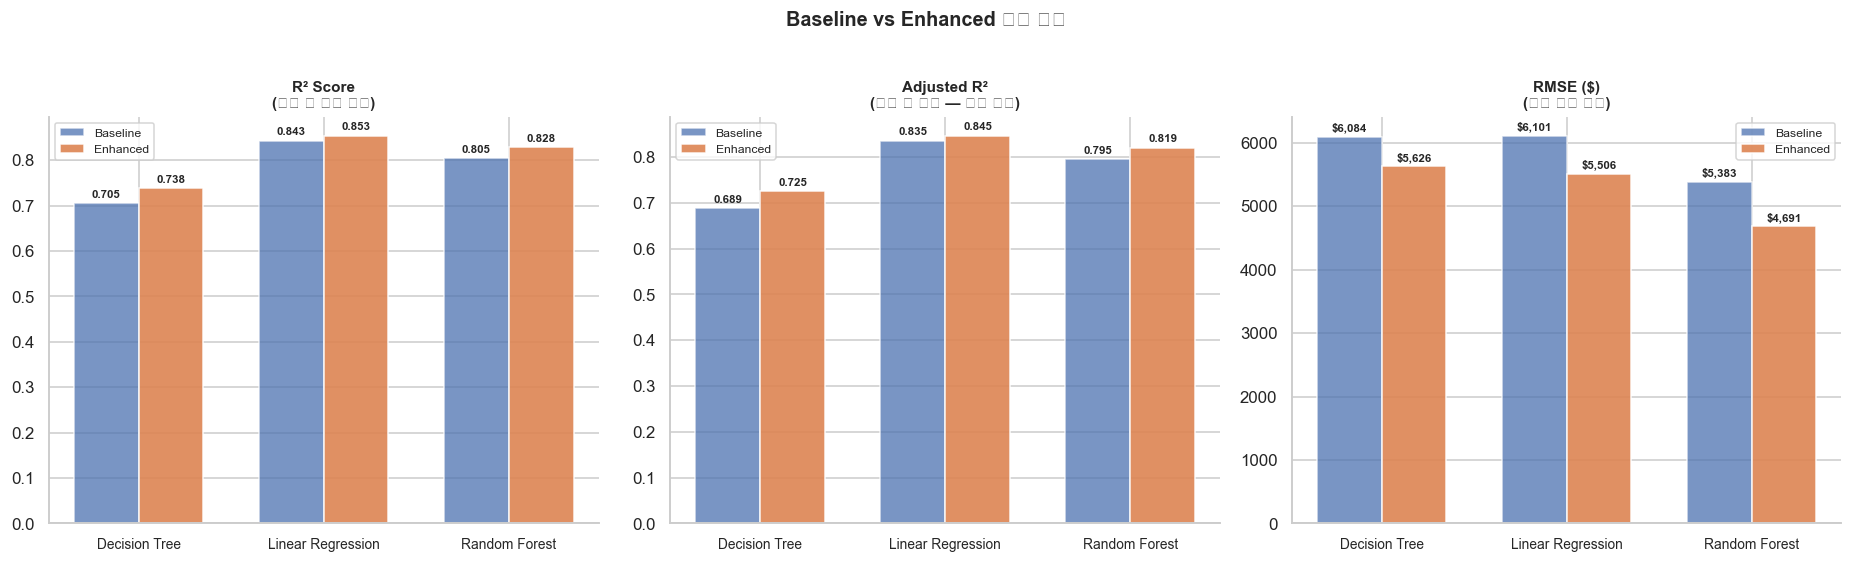

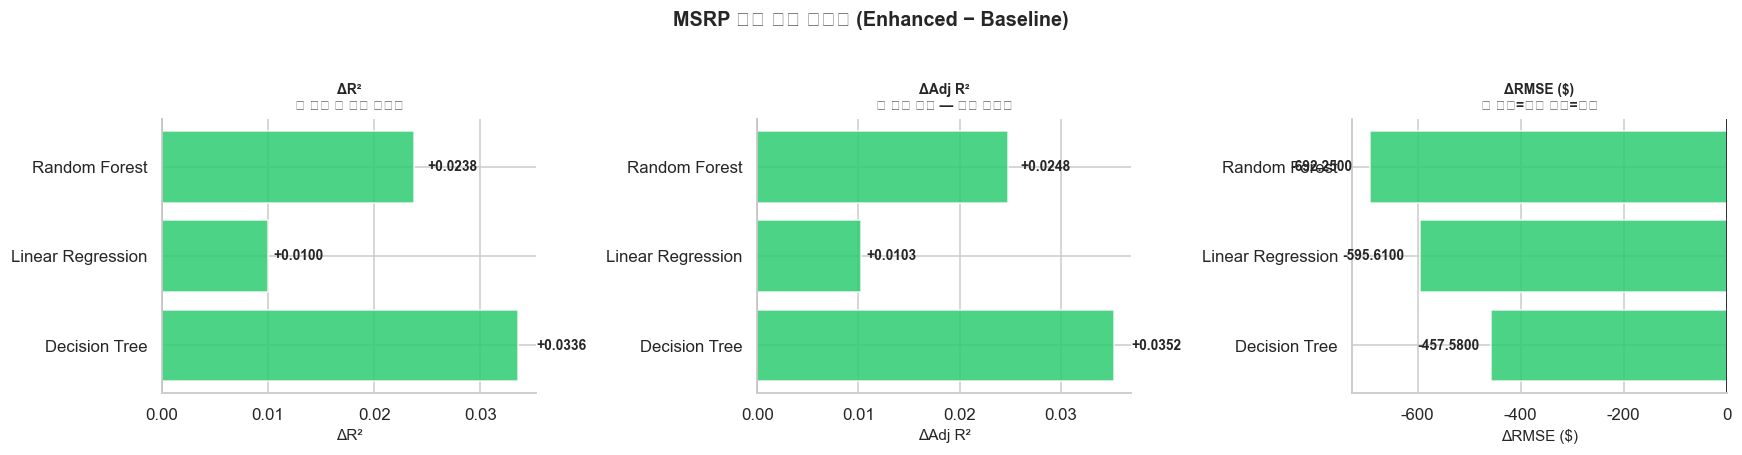

In [ ]:
# ── (A) 3종 지표 Grouped Bar ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (metric, title, fmt) in zip(axes, [
    ('R2',   'R² Score\n(피처 수 효과 포함)',         '{:.3f}'),
    ('Adj_R2','Adjusted R²\n(피처 수 보정 — 핵심 지표)', '{:.3f}'),
    ('RMSE', 'RMSE ($)\n(실제 달러 오차)',             '${:,.0f}'),
]):
    pv = main_df.pivot(index='Model', columns='Version', values=metric)
    x  = np.arange(len(pv)); w = 0.35
    b1 = ax.bar(x-w/2, pv['Baseline'], w, label='Baseline',
                color='#4C72B0', alpha=0.75)
    b2 = ax.bar(x+w/2, pv['Enhanced'], w, label='Enhanced',
                color='#DD8452', alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(pv.index, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h*1.01,
                fmt.format(h), ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

plt.suptitle("Baseline vs Enhanced 성능 비교",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── (B) MSRP 피처 기여도 Delta 수평 막대 ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, xlabel, note, invert) in zip(axes, [
    ('ΔR2',     'ΔR²',     '※ 피처 수 효과 미보정',      False),
    ('ΔAdj_R2', 'ΔAdj R²', '※ 핵심 지표 — 실질 기여도',  False),
    ('ΔRMSE',   'ΔRMSE ($)','※ 음수=오차 감소=개선',      True),
]):
    vals = pivot.set_index('Model')[col]
    good = lambda v: (v >= 0) if not invert else (v <= 0)
    colors = ['#2ecc71' if good(v) else '#e74c3c' for v in vals]
    ax.barh(vals.index, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(f"{xlabel}\n{note}", fontsize=9, fontweight='bold')
    for i, v in enumerate(vals):
        off = abs(v)*0.05 if v != 0 else 1e-4
        ax.text(v+(off if v>=0 else -off), i,
                f'{v:+.4f}', va='center',
                ha='left' if v>=0 else 'right',
                fontsize=9, fontweight='bold')

plt.suptitle("MSRP 피처 실질 기여도 (Enhanced − Baseline)",
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


MSRP feature 추가 이후 모든 모델에서 R²가 증가하였다.
이는 MSRP 정보가 중고차 가격 설명력 향상에 기여했음을 의미한다.
특히 Decision Tree 모델에서 가장 큰 성능 향상이 나타났다.

Adjusted R² 역시 모든 모델에서 증가하였다.
이는 MSRP feature가 단순히 변수 수를 증가시킨 것이 아니라,
실질적으로 예측 성능 향상에 기여했음을 의미한다.

Random Forest Enhanced 모델은
가장 낮은 RMSE를 기록하였다.
이는 실제 차량 가격과의 예측 오차가 가장 작았음을 의미하며,
실무적 관점에서 가장 우수한 예측 성능을 보였다.

(1) ΔR² 그래프 -> Decision Tree가 가장 큼.

(2) ΔAdjusted R² 그래프 -> 모든 모델에서 양수(+)

(3) ΔRMSE 그래프 -> 음수 방향으로 클수록 좋음

## Step 8. 회귀계수 분석 (Linear Regression)

Linear Regression 모델의 회귀계수를 확인하여
각 feature가 차량 가격 예측에 미치는 영향의 방향성을 분석하였다.

양수 계수는 해당 feature 값이 증가할수록 예측 가격이 증가하는 경향을,
음수 계수는 예측 가격이 감소하는 경향을 의미한다.

다만 feature의 scale과 encoding 방식에 따라 계수의 절댓값 크기가 달라질 수 있으므로,
계수 크기만으로 feature 중요도를 단정하지 않고 해석에 주의하였다.

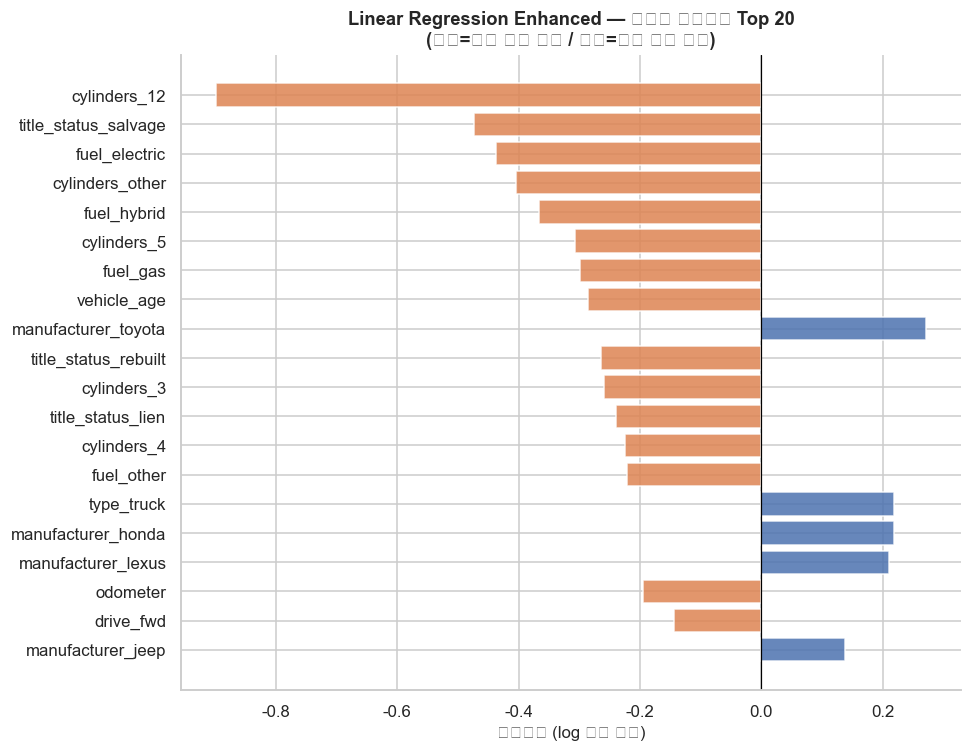

[상위 10개 — 가격 상승 기여]
             Feature  Coefficient
        cylinders_12    -0.898022
title_status_salvage    -0.473825
       fuel_electric    -0.436314
     cylinders_other    -0.403387
         fuel_hybrid    -0.366115
         cylinders_5    -0.307205
            fuel_gas    -0.297937
         vehicle_age    -0.285345
 manufacturer_toyota     0.271533
title_status_rebuilt    -0.263721

[하위 10개 — 가격 하락 기여]
                   Feature  Coefficient
           paint_color_red     0.023921
        transmission_other     0.020947
manufacturer_mercedes-benz     0.019068
       manufacturer_nissan    -0.017685
          paint_color_blue    -0.016043
                 drive_rwd     0.012354
        manufacturer_dodge     0.007925
        manufacturer_other     0.001828
          paint_color_grey    -0.000594
             estimate_msrp     0.000010


In [ ]:
lr_enh = fitted_models["Linear Regression_Enhanced"]

coef_df = pd.DataFrame({
    'Feature':     X_train_enh.columns,
    'Coefficient': lr_enh.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

# 상위 20개 피처
top_n   = 20
top_c   = coef_df.head(top_n)
colors  = ['#4C72B0' if v >= 0 else '#DD8452' for v in top_c['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_c['Feature'][::-1], top_c['Coefficient'][::-1],
        color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('회귀계수 (log 가격 기준)', fontsize=11)
ax.set_title(f'Linear Regression Enhanced — 피처별 회귀계수 Top {top_n}\n'
             f'(파랑=가격 상승 기여 / 주황=가격 하락 기여)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("[상위 10개 — 가격 상승 기여]")
print(coef_df.head(10)[['Feature','Coefficient']].to_string(index=False))
print("\n[하위 10개 — 가격 하락 기여]")
print(coef_df.tail(10)[['Feature','Coefficient']].to_string(index=False))


## Step 9. 실제 가격 vs 예측 가격 비교 및 잔차 분석

먼저 성능 지표 기준으로 가장 우수한 모델을 선택하여
실제 가격과 예측 가격의 관계를 시각화하였다.

이를 통해 모델이 전반적으로 실제 가격을 잘 따라가는지 확인하였다.

추가로 Linear Regression 모델에 대해서는 잔차 분석을 수행하여
정규성, 등분산성 등 회귀 모델의 기본 가정을 사후적으로 점검하였다.

최고 성능 모델: Linear Regression (Enhanced)
  Adj R² = 0.8452 | RMSE = $5,506


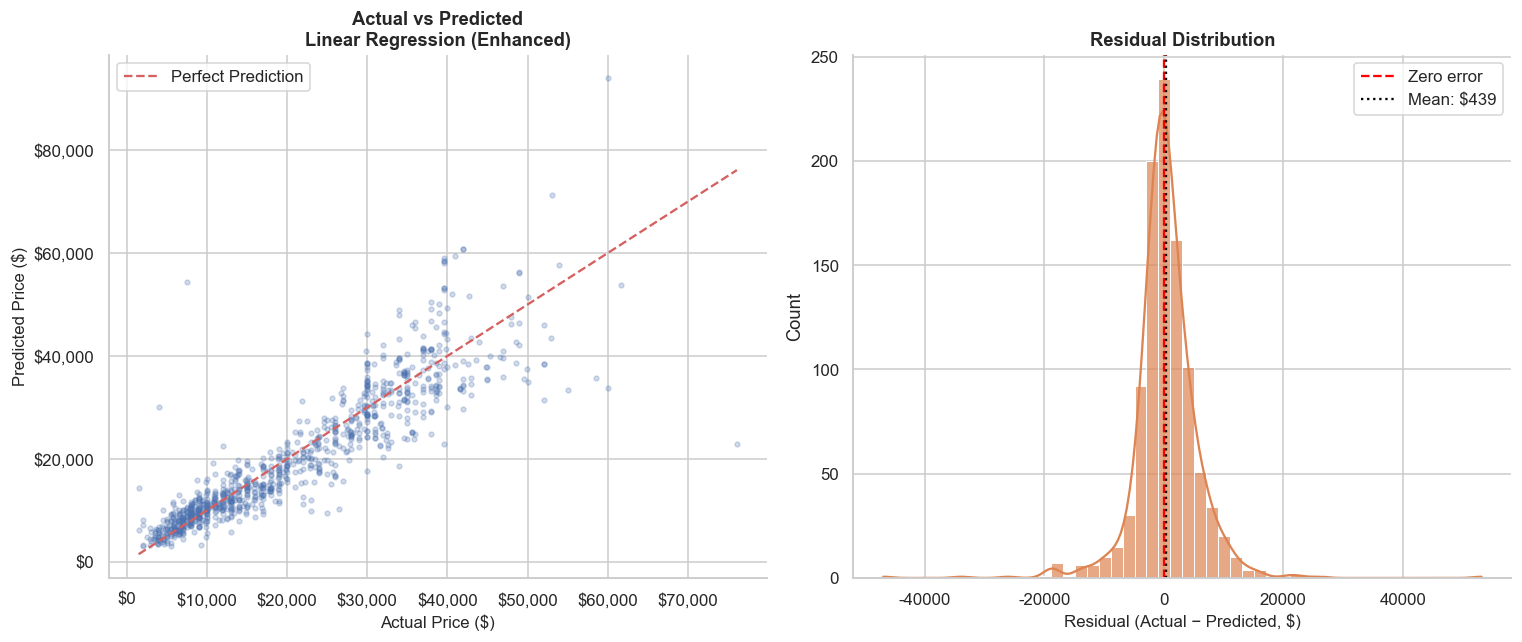

In [ ]:
# 최고 성능 모델 (Adj R² 기준 자동 선택)
best_row     = main_df.sort_values('Adj_R2', ascending=False).iloc[0]
best_name    = best_row['Model']
best_version = best_row['Version']
best_m       = fitted_models[f"{best_name}_{best_version}"]
X_te_best    = X_test_enh if best_version == "Enhanced" else X_test_base
pred_log_best = best_m.predict(X_te_best)

print(f"최고 성능 모델: {best_name} ({best_version})")
print(f"  Adj R² = {best_row['Adj_R2']:.4f} | RMSE = ${best_row['RMSE']:,.0f}")

y_actual  = np.expm1(y_test_log)
y_pred    = np.expm1(pred_log_best)
residuals = y_actual - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 산점도
ax = axes[0]
ax.scatter(y_actual, y_pred, alpha=0.25, s=10, color='#4C72B0')
lim = [y_actual.min(), y_actual.max()]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel("Actual Price ($)", fontsize=11)
ax.set_ylabel("Predicted Price ($)", fontsize=11)
ax.set_title(f"Actual vs Predicted\n{best_name} ({best_version})",
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend()

# 잔차 분포
ax = axes[1]
sns.histplot(residuals, bins=50, kde=True, color='#DD8452', ax=ax, alpha=0.7)
ax.axvline(0,               color='red',   linestyle='--', linewidth=1.5,
           label='Zero error')
ax.axvline(residuals.mean(),color='black', linestyle=':',  linewidth=1.5,
           label=f'Mean: ${residuals.mean():,.0f}')
ax.set_xlabel("Residual (Actual − Predicted, $)", fontsize=11)
ax.set_title("Residual Distribution", fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


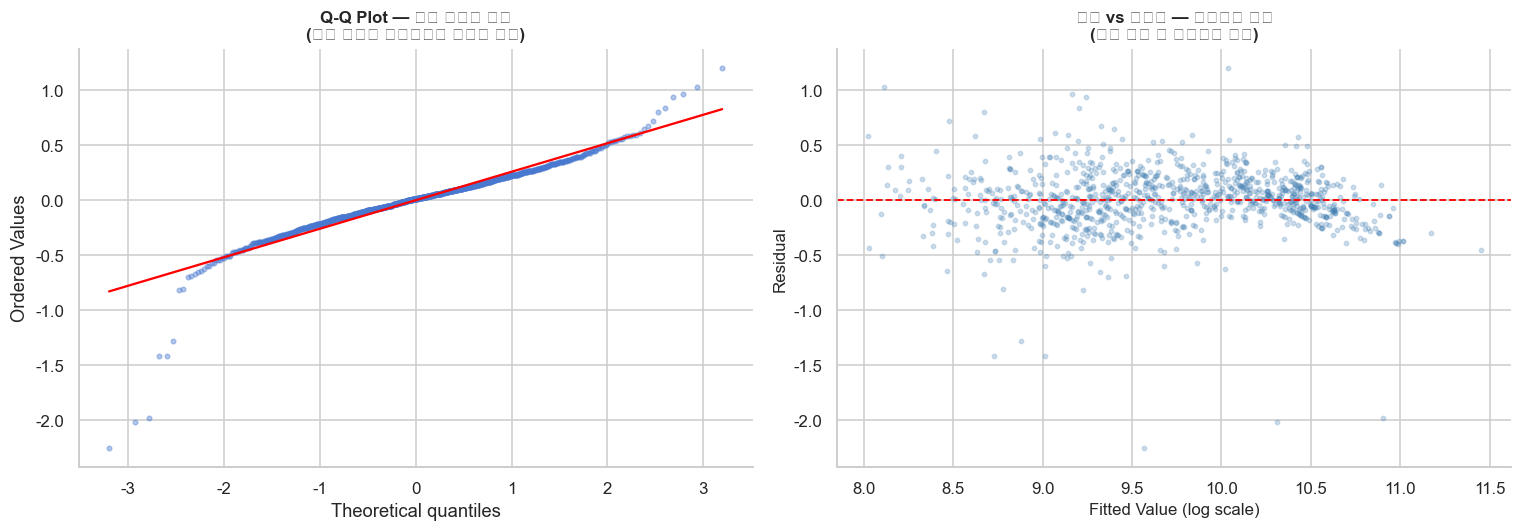

In [ ]:
# Linear Regression 가정 검증 (잔차 정규성 · 등분산성)
lr_pred_log = fitted_models["Linear Regression_Enhanced"].predict(X_test_enh)
lr_resid    = y_test_log - lr_pred_log   # log 스케일 잔차

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot — 정규성
ax = axes[0]
stats.probplot(lr_resid, dist="norm", plot=ax)
ax.set_title("Q-Q Plot — 잔차 정규성 검증\n(점이 직선에 가까울수록 정규성 만족)",
             fontsize=11, fontweight='bold')
ax.get_lines()[0].set(markersize=3, alpha=0.4)
ax.get_lines()[1].set(color='red', linewidth=1.5)

# 잔차 vs 예측값 — 등분산성
ax = axes[1]
ax.scatter(lr_pred_log, lr_resid, alpha=0.25, s=8, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax.set_xlabel("Fitted Value (log scale)", fontsize=11)
ax.set_ylabel("Residual", fontsize=11)
ax.set_title("잔차 vs 예측값 — 등분산성 검증\n(균등 분포 시 등분산성 만족)",
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## Step 10. 이상점(Outlier) 및 영향점(Influential Point) 분석

- **이상점**: 표준화 잔차 절댓값 > 3 인 관측치
- **영향점**: Cook's Distance > 4/n 인 관측치

> 모든 이상점을 제거하는 것이 옳은 것은 아니다.  
> 해당 관측치가 실무적으로 타당한 데이터인지 맥락을 파악한 후 유지/제거 여부를 판단해야 한다.


표준화 잔차 > 3 이상점: 39개 (1.0%)

Cook's Distance > 4/n 영향점: 23개

[Cook's Distance 상위 5개 관측치]
      odometer  vehicle_age  estimate_msrp  price_log
4214 -1.188011    -0.631341        80000.0  11.155550
2021 -0.138037    -0.631341        30500.0   9.798127
2663 -0.914608    -1.339520        26500.0   9.928229
1714 -0.726734    -0.867401        33500.0   9.510519
1477  0.686122     0.548957       242000.0   9.093919


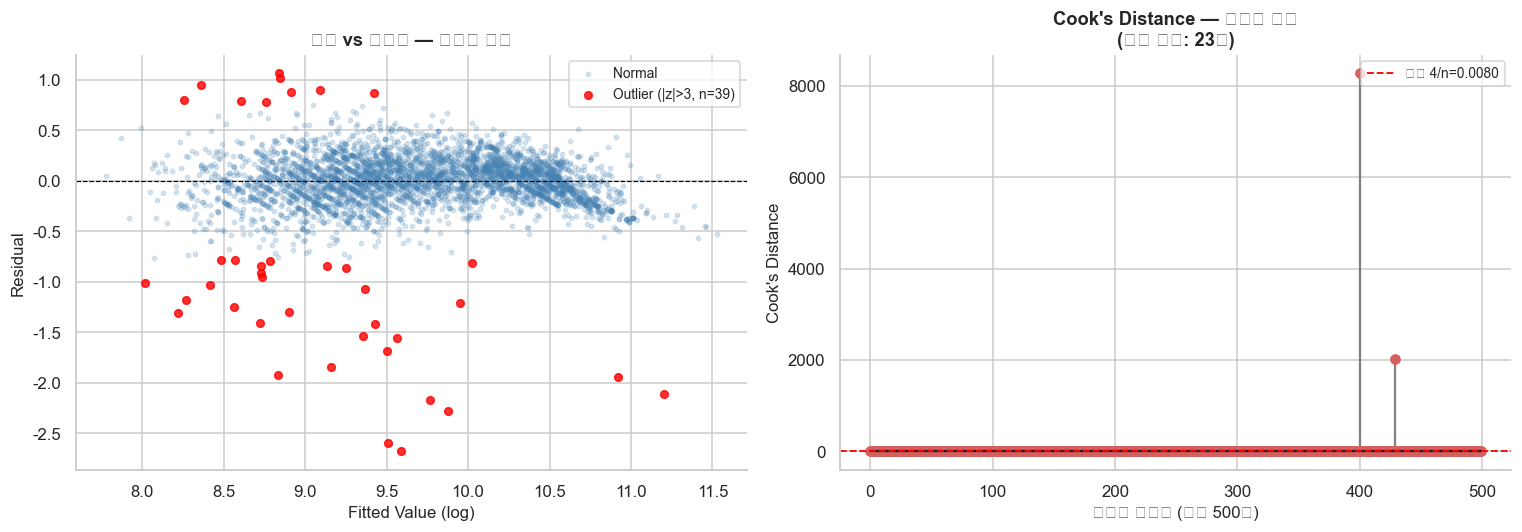

In [ ]:
lr_m      = fitted_models["Linear Regression_Enhanced"]
pred_tr   = lr_m.predict(X_train_enh)
resid_tr  = y_train_log - pred_tr
resid_std = (resid_tr - resid_tr.mean()) / resid_tr.std()

outlier_mask = resid_std.abs() > 3
print(f"표준화 잔차 > 3 이상점: {outlier_mask.sum()}개 "
      f"({outlier_mask.sum()/len(resid_std)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 잔차 vs 예측값 (이상점 강조)
ax = axes[0]
ax.scatter(pred_tr[~outlier_mask], resid_tr[~outlier_mask],
           alpha=0.2, s=8,  color='steelblue', label='Normal')
ax.scatter(pred_tr[outlier_mask],  resid_tr[outlier_mask],
           alpha=0.8, s=25, color='red',
           label=f'Outlier (|z|>3, n={outlier_mask.sum()})')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Fitted Value (log)", fontsize=11)
ax.set_ylabel("Residual", fontsize=11)
ax.set_title("잔차 vs 예측값 — 이상점 탐지",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Cook's Distance (샘플 500개)
ax = axes[1]
try:
    n_sample = min(500, len(X_train_enh))
    X_ols = add_constant(X_train_enh.values[:n_sample])
    y_ols = y_train_log.values[:n_sample]
    ols_res    = OLS(y_ols, X_ols).fit()
    cooks_d    = ols_res.get_influence().cooks_distance[0]
    threshold  = 4 / n_sample
    influential = cooks_d > threshold

    ax.stem(np.arange(len(cooks_d)), cooks_d,
            markerfmt='ro', linefmt='grey', basefmt='k-')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
               label=f"기준 4/n={threshold:.4f}")
    ax.set_xlabel(f"관측치 인덱스 (샘플 {n_sample}개)", fontsize=11)
    ax.set_ylabel("Cook's Distance", fontsize=11)
    ax.set_title(f"Cook's Distance — 영향점 탐지\n"
                 f"(기준 초과: {influential.sum()}개)",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    print(f"\nCook's Distance > 4/n 영향점: {influential.sum()}개")
    top5 = np.argsort(cooks_d)[-5:][::-1]
    sample_ref = pd.concat([X_train_enh, y_train_log.rename('price_log')],
                            axis=1).iloc[:n_sample]
    num_show = [c for c in ['odometer','vehicle_age','estimate_msrp','price_log']
                if c in sample_ref.columns]
    print("\n[Cook's Distance 상위 5개 관측치]")
    print(sample_ref.iloc[top5][num_show])

except Exception as e:
    ax.text(0.5, 0.5, f"계산 오류\n{e}", transform=ax.transAxes, ha='center')
    print(f"Cook's Distance 계산 오류: {e}")

plt.tight_layout()
plt.show()
